<a href="https://colab.research.google.com/github/MehdiSaraeian/Classification/blob/add-workshop-scenarios/scenarios/01-logistic-regression/Scenario_1_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 1: Your First Classifier: Predicting Outcomes with Logistic Regression

Welcome to the first scenario! Here, we'll build a Logistic Regression model to predict whether a breast cancer tumor is benign or malignant.

## 1. Import Necessary Libraries

First, let's import all the Python libraries we'll need for this task.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load the Dataset

The dataset is in a file named `breast-cancer-wisconsin.data`. It doesn't have a header row, so we need to provide the column names when we load it.

In [10]:
# HINT: The column names are provided. Use pd.read_csv() to load the data.
# Don't forget to pass the `names` parameter!
column_names = [
    'id', 'clump_thickness', 'unif_cell_size', 'unif_cell_shape',
    'marg_adhesion', 'single_epith_cell_size', 'bare_nuclei',
    'bland_chrom', 'norm_nucleoli', 'mitoses', 'class'
]

# YOUR CODE HERE
df = pd.read_csv('/content/breast-cancer-wisconsin.data', names=column_names)

# Display the first 5 rows to verify it's loaded correctly
print(df.head())

        id  clump_thickness  unif_cell_size  unif_cell_shape  marg_adhesion  \
0  1000025                5               1                1              1   
1  1002945                5               4                4              5   
2  1015425                3               1                1              1   
3  1016277                6               8                8              1   
4  1017023                4               1                1              3   

   single_epith_cell_size bare_nuclei  bland_chrom  norm_nucleoli  mitoses  \
0                       2           1            3              1        1   
1                       7          10            3              2        1   
2                       2           2            3              1        1   
3                       3           4            3              7        1   
4                       2           1            3              1        1   

   class  
0      2  
1      2  
2      2  
3      2  
4

## 3. Preprocess the Data

Real-world data is often messy. We need to:
1.  Handle missing values. The `bare_nuclei` column has `'?'` for missing data.
2.  Drop the `id` column, as it's not useful for prediction.
3.  Map the `class` column to `0` and `1` for easier use with our model.

In [11]:
# HINT: First, replace '?' with np.nan. Then, use .fillna() with the column's median.
# Finally, drop the 'id' column using df.drop().

# Replace '?' with NaN and convert column to numeric
df['bare_nuclei'] = df['bare_nuclei'].replace('?', np.nan)
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'])

# YOUR CODE HERE to impute missing values with the median
median_bare_nuclei = df['bare_nuclei'].median()
df.fillna({'bare_nuclei': median_bare_nuclei}, inplace=True)

# YOUR CODE HERE to drop the 'id' column
df.drop('id', axis=1, inplace=True)

# Map the 'class' column (2 for benign, 4 for malignant) to 0 and 1
df['class'] = df['class'].map({2: 0, 4: 1})

# Verify the changes
print(df.head())
print(f"\nMissing values after cleaning: {df['bare_nuclei'].isnull().sum()}")

   clump_thickness  unif_cell_size  unif_cell_shape  marg_adhesion  \
0                5               1                1              1   
1                5               4                4              5   
2                3               1                1              1   
3                6               8                8              1   
4                4               1                1              3   

   single_epith_cell_size  bare_nuclei  bland_chrom  norm_nucleoli  mitoses  \
0                       2          1.0            3              1        1   
1                       7         10.0            3              2        1   
2                       2          2.0            3              1        1   
3                       3          4.0            3              7        1   
4                       2          1.0            3              1        1   

   class  
0      0  
1      0  
2      0  
3      0  
4      0  

Missing values after cleaning: 0


## 4. Define Features (X) and Target (y) and Split the Data

Now we separate our data into the features (`X`) we'll use for prediction and the target (`y`) we want to predict. Then we split them into training and testing sets.

In [12]:
# HINT: X should be all columns *except* 'class'. y is the 'class' column.
# Use train_test_split with a test_size of 0.2 and random_state=42.

# YOUR CODE HERE
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 5. Feature Scaling

Logistic Regression benefits from feature scaling. We'll use `StandardScaler` to scale our data so that each feature has a mean of 0 and a standard deviation of 1.

In [13]:
# HINT: Create a StandardScaler, fit it on the training data, and transform both the training and test data.

# YOUR CODE HERE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Train the Logistic Regression Model

It's time to train our model!

In [14]:
# HINT: Create an instance of LogisticRegression and use the .fit() method on the scaled training data.

# YOUR CODE HERE
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

## 7. Make Predictions and Evaluate the Model

Let's see how well our model performs on the unseen test data.

In [15]:
# HINT: Use model.predict() on the scaled test data. Then use accuracy_score(), confusion_matrix(), and classification_report() to evaluate.

# YOUR CODE HERE
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9500

Confusion Matrix:
[[89  3]
 [ 4 44]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        92
           1       0.94      0.92      0.93        48

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.94       140
weighted avg       0.95      0.95      0.95       140



## 8. Visualize the Confusion Matrix

A heatmap is a great way to visualize the confusion matrix.

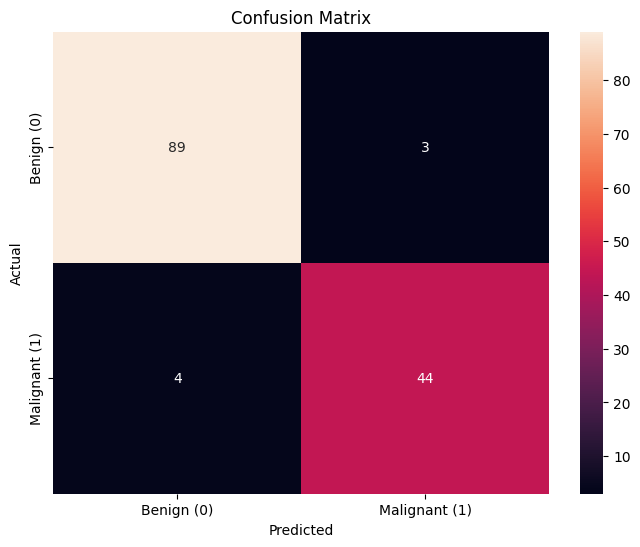

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()